# Training Script for LSTM PyTorch Multi-Day Forecaster

## Settings and Imports

In [1]:
import os

import torch
import torch.optim as optim
import torch.nn as nn

import numpy as np

from utils.data_preparation import (
    prepare_data_for_modeling,
    prepare_lstm_loaders_with_target_scaling,
)
from utils.lstm_model import LSTMForecaster
from utils.train_lstm_multiday import train_one_epoch_multiday

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
BEST_MODEL_PATH = os.path.join("models", "production_lstm_multiday_load_forecaster.pt")

REPROCESS_DATA = True  # Set to True to reprocess the data and overwrite existing files

# # Default date ranges for training, validation, and testing. 
# TRAIN_START_DATE = "2018-01-01"
# TRAIN_END_DATE = "2023-12-31"
# VALIDATION_START_DATE = "2024-01-01"
# VALIDATION_END_DATE = "2024-12-31"
# TEST_START_DATE = "2025-01-01"
# TEST_END_DATE = "2025-12-31"

# Default date ranges for training, validation, and testing. 
TRAIN_START_DATE = "2022-01-01"
TRAIN_END_DATE = "2025-12-31"
VALIDATION_START_DATE = "2026-01-01"
VALIDATION_END_DATE = "2026-03-07"
TEST_START_DATE = "2026-01-01"  # Same as validation, but we won't use it.
TEST_END_DATE = "2026-03-07"

TRAINING = True  # Set to True to train the model
TEST = True  # Set to True to evaluate the model on the test set
BATCH_SIZE = 32
EPOCHS = 3000
LEARNING_RATE = 5e-4
WINDOW_SIZE = 21  # Number of days to look back for the LSTM model
VALIDATE_EVERY = 10
EARLY_STOPPING_PATIENCE = 20
MIN_IMPROVEMENT = 1e-4

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

# This features describe the today's weather and load.
# Features NOT included:
# - lag and std features, because they are derived from the load feature by the model
# - weather features with low importance according to the XGBoost feature importance plot (e.g. cloud cover, sunshine duration, wind speed, heating/cooling degrees)
FEATURES_TODAY = ['Temp', 'Min Temp', 'Max Temp', 'load']

# These features describe the features of the next day (e.g. holiday and cyclic calendar terms).
FEATURES_TARGET_TIME = ['is_holiday', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

FEATURES = FEATURES_TODAY + FEATURES_TARGET_TIME

# We will predict the load of the next day
TARGETS = ["load_t+1", "load_t+2", "load_t+3", "load_t+4", "load_t+5", "load_t+6", "load_t+7"]

SCALE_FEATURES = FEATURES_TODAY

Using device: mps


## Dataset Loading and Preparation

In [2]:
data_dict, _ = prepare_data_for_modeling(
    FEATURES, TARGETS, SCALE_FEATURES, save_scaler=True, save_data=True,
    train_start_date=TRAIN_START_DATE, train_end_date=TRAIN_END_DATE,
    val_start_date=VALIDATION_START_DATE, val_end_date=VALIDATION_END_DATE,
    test_start_date=TEST_START_DATE, test_end_date=TEST_END_DATE,
    reprocess_data=REPROCESS_DATA,
    production_data=False
)

prepared_data = prepare_lstm_loaders_with_target_scaling(
    data_dict=data_dict,
    window_size=WINDOW_SIZE,
    batch_size=BATCH_SIZE,
    training=TRAINING,
    test=TEST,
)

y_train_raw = prepared_data["y_train_raw"]
y_val_raw = prepared_data["y_val_raw"]
y_test_raw = prepared_data["y_test_raw"]

y_train = prepared_data["y_train"]
y_val = prepared_data["y_val"]
y_test = prepared_data["y_test"]

target_mean = prepared_data["target_mean"]
target_std = prepared_data["target_std"]

if TRAINING:
    training_loader = prepared_data["training_loader"]
    validation_loader = prepared_data["validation_loader"]

if TEST:
    test_loader = prepared_data["test_loader"]
    test_df = prepared_data["test_df"]  # For the timestamps

Target scaling ->
mean: {'load_t+1': 53328.23, 'load_t+2': 53322.59, 'load_t+3': 53319.63, 'load_t+4': 53307.53, 'load_t+5': 53300.22, 'load_t+6': 53290.54, 'load_t+7': 53278.65}
std: {'load_t+1': 6408.3, 'load_t+2': 6409.13, 'load_t+3': 6408.88, 'load_t+4': 6398.38, 'load_t+5': 6390.18, 'load_t+6': 6377.5, 'load_t+7': 6362.95}


## Training Setup

In [3]:
model = LSTMForecaster(input_size=len(FEATURES),
                       hidden_size=64, num_layers=1, output_size=len(TARGETS), dropout=0.0).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.SmoothL1Loss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    threshold=MIN_IMPROVEMENT,
    threshold_mode="abs",
)

## Training

In [4]:
if TRAINING:
    best_val_mse = float("inf")
    best_epoch = -1
    epochs_without_improvement = 0

    for epoch in range(1, EPOCHS + 1):
        best_val_mse, best_epoch, epochs_without_improvement, should_stop = train_one_epoch_multiday(
            epoch=epoch,
            best_val_mse=best_val_mse,
            best_epoch=best_epoch,
            epochs_without_improvement=epochs_without_improvement,
            model=model,
            loss_fn=loss_fn,
            optimizer=optimizer,
            window_size=WINDOW_SIZE,
            features=FEATURES,
            targets=TARGETS,
            best_model_path=BEST_MODEL_PATH,
            target_mean=target_mean,
            target_std=target_std,
            scheduler=scheduler,
            min_improvement=MIN_IMPROVEMENT,
            device=DEVICE,
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            validate_every=VALIDATE_EVERY,
            training_loader=training_loader,
            validation_loader=validation_loader,
        )
        if should_stop:
            break

    if best_epoch == -1:
        print(
            "Training finished without a validation checkpoint. "
            "Increase EPOCHS or reduce VALIDATE_EVERY."
        )
    else:
        print(
            f"Best model saved to {BEST_MODEL_PATH} "
            f"(epoch {best_epoch}, val MSE {best_val_mse:.6f})"
        )

Epoch 10: train RMSE 0.4174, train MAE 0.2872, val RMSE 0.3862, val MAE 0.3284, val MSE 0.1492, val pred std 0.70, lr 5.00e-04 [saved best]
Epoch 20: train RMSE 0.3543, train MAE 0.2341, val RMSE 0.3796, val MAE 0.3118, val MSE 0.1441, val pred std 0.76, lr 5.00e-04 [saved best]
Epoch 30: train RMSE 0.3238, train MAE 0.2137, val RMSE 0.4156, val MAE 0.3327, val MSE 0.1728, val pred std 0.75, lr 5.00e-04
Epoch 40: train RMSE 0.3003, train MAE 0.1983, val RMSE 0.3105, val MAE 0.2556, val MSE 0.0964, val pred std 0.78, lr 5.00e-04 [saved best]
Epoch 50: train RMSE 0.2844, train MAE 0.1892, val RMSE 0.3425, val MAE 0.2731, val MSE 0.1173, val pred std 0.78, lr 5.00e-04
Epoch 60: train RMSE 0.2716, train MAE 0.1806, val RMSE 0.3354, val MAE 0.2712, val MSE 0.1125, val pred std 0.77, lr 5.00e-04
Epoch 70: train RMSE 0.2584, train MAE 0.1737, val RMSE 0.3927, val MAE 0.3023, val MSE 0.1542, val pred std 0.78, lr 5.00e-04
Epoch 80: train RMSE 0.2435, train MAE 0.1656, val RMSE 0.3271, val MAE 

Using target inverse scaling from checkpoint metadata.
Processing target 'load_t+1' with offset of 1 day(s) for plotting.
Processing target 'load_t+2' with offset of 2 day(s) for plotting.
Processing target 'load_t+3' with offset of 3 day(s) for plotting.
Processing target 'load_t+4' with offset of 4 day(s) for plotting.
Processing target 'load_t+5' with offset of 5 day(s) for plotting.
Processing target 'load_t+6' with offset of 6 day(s) for plotting.
Processing target 'load_t+7' with offset of 7 day(s) for plotting.
Multi-target metrics:
load_t+1 -> MAE: 997.93, RMSE: 1200.88
load_t+2 -> MAE: 1292.25, RMSE: 1489.10
load_t+3 -> MAE: 1624.15, RMSE: 1898.21
load_t+4 -> MAE: 1616.15, RMSE: 1952.06
load_t+5 -> MAE: 1884.86, RMSE: 2276.71
load_t+6 -> MAE: 2055.25, RMSE: 2500.01
load_t+7 -> MAE: 1962.12, RMSE: 2244.48


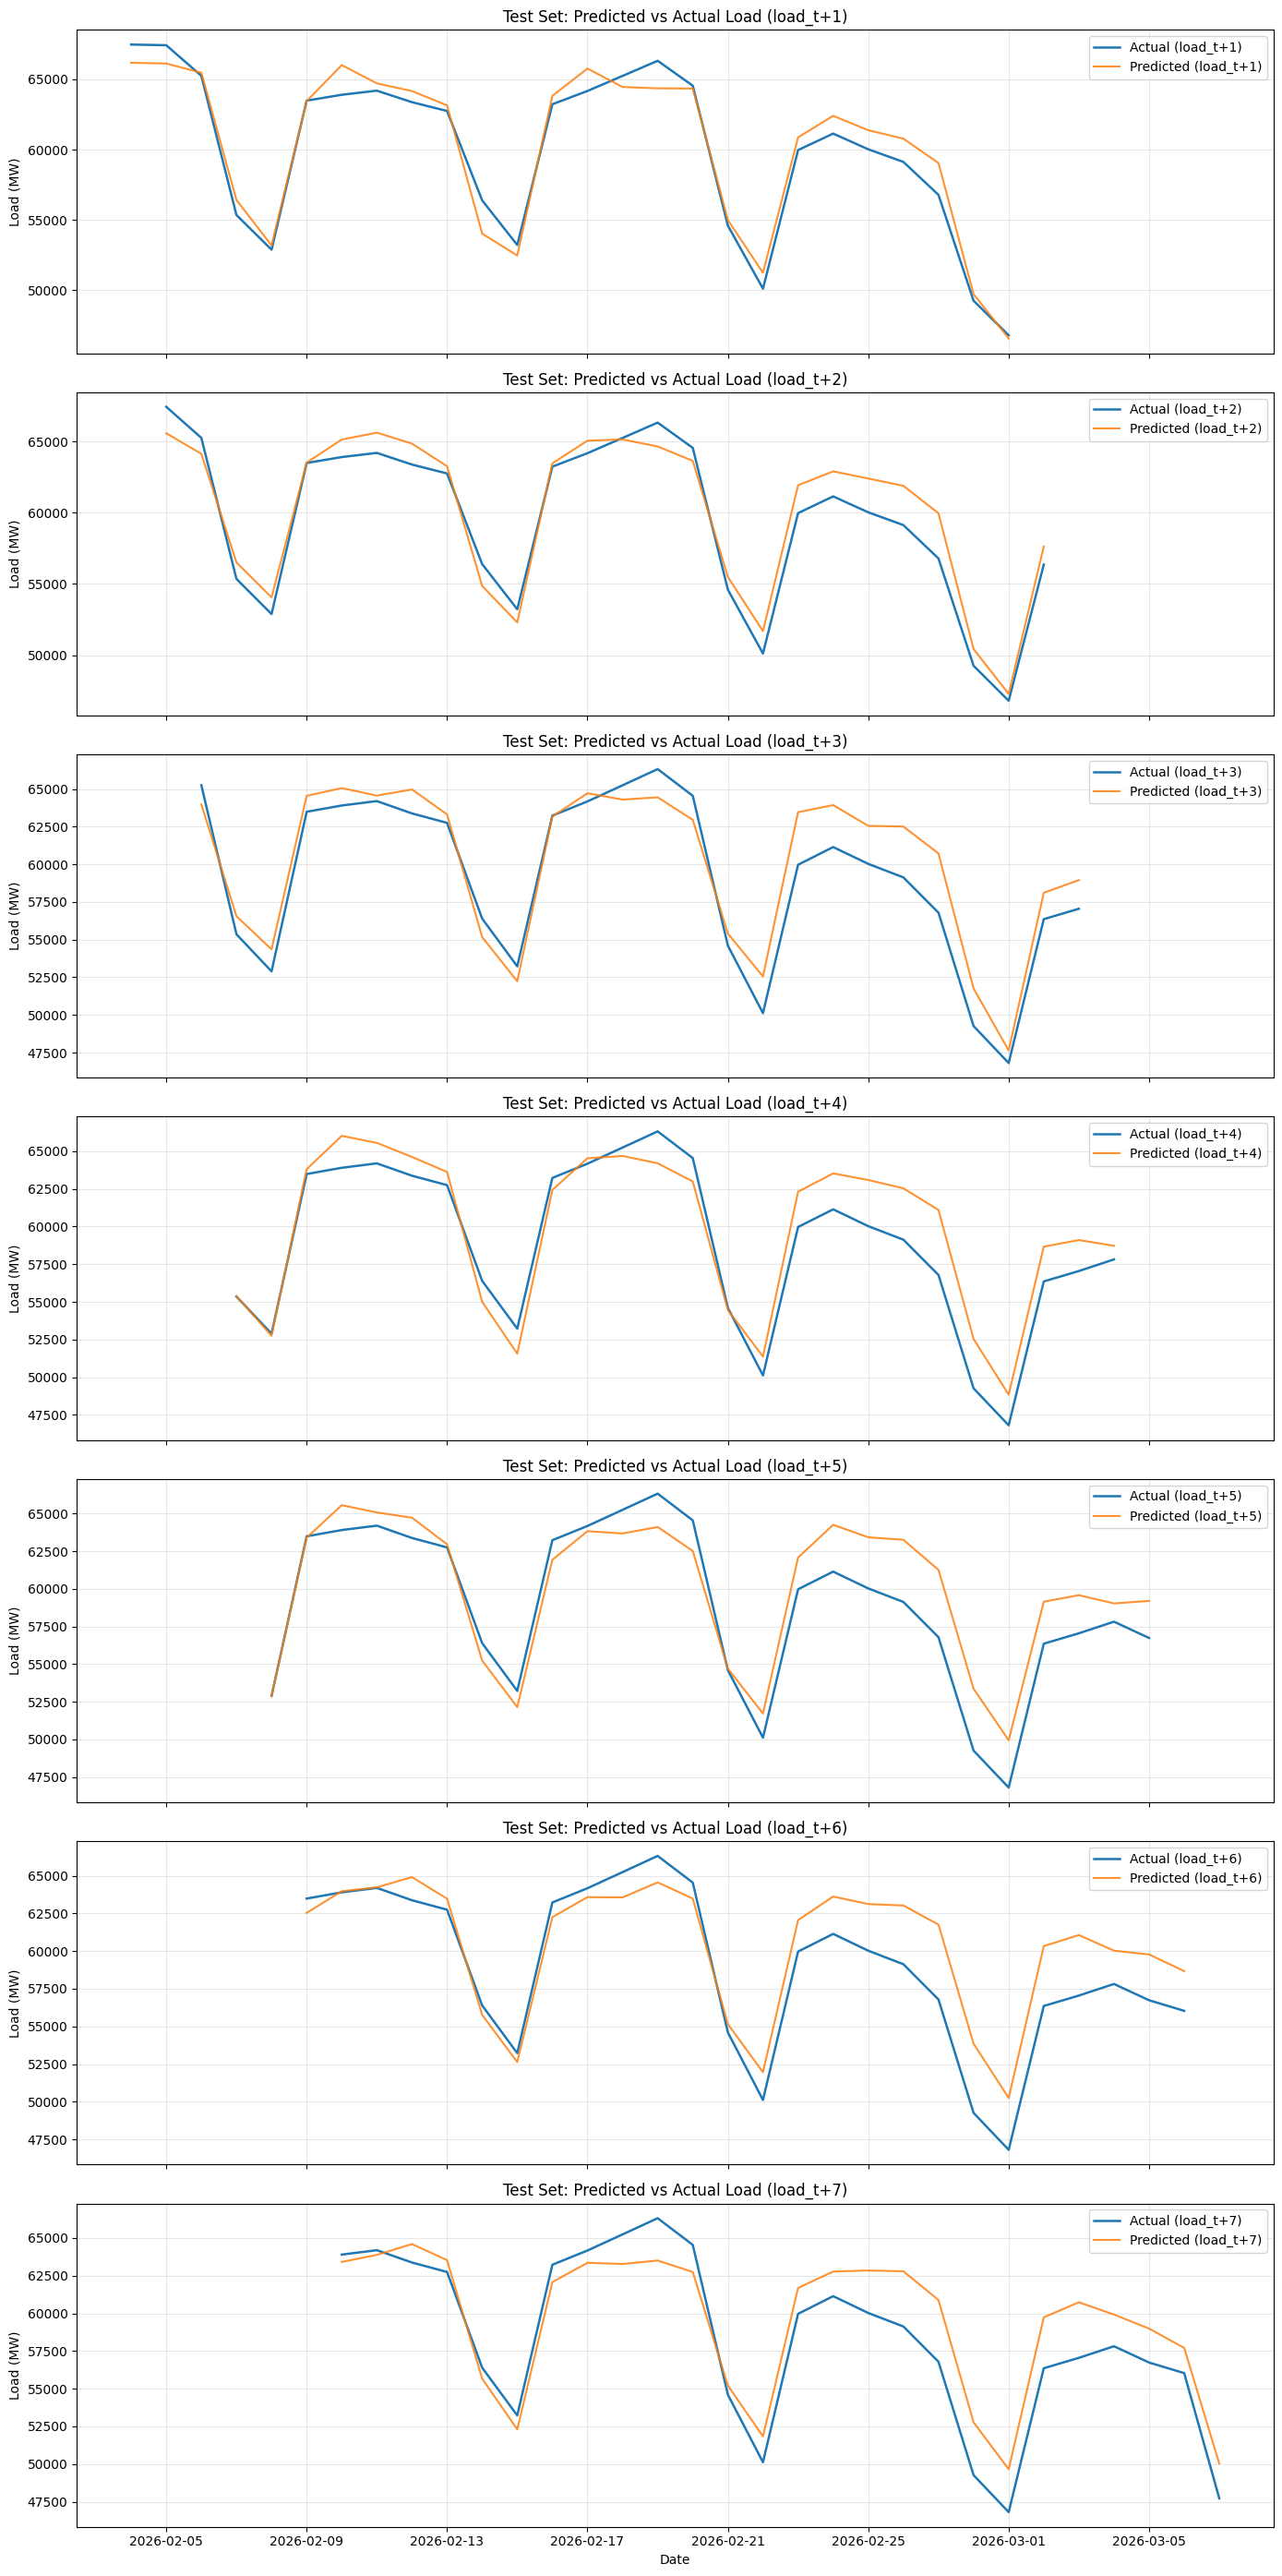

In [5]:
from utils.visualize_model_performance import evaluate_and_plot_model_torch
import numpy as np

if TEST:
    if not os.path.exists(BEST_MODEL_PATH):
        raise FileNotFoundError(
            f"Saved model not found at {BEST_MODEL_PATH}. "
            "Run training first with TRAINING=True to create a compatible checkpoint."
        )

    checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
    checkpoint_target_scaled = False

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model_state_dict = checkpoint["model_state_dict"]
        checkpoint_target_scaled = bool(checkpoint.get("target_scaled", False))
        ckpt_target_mean = np.asarray(checkpoint.get("target_mean", target_mean.to_numpy()))
        ckpt_target_std = np.asarray(checkpoint.get("target_std", target_std.to_numpy()))
    else:
        # Backward compatibility for legacy checkpoints saved as raw state_dict.
        model_state_dict = checkpoint
        ckpt_target_mean = target_mean.to_numpy()
        ckpt_target_std = target_std.to_numpy()

    try:
        model.load_state_dict(model_state_dict)
    except RuntimeError as exc:
        raise RuntimeError(
            "Checkpoint is incompatible with current model/features. "
            "Please retrain with TRAINING=True so a new checkpoint is saved. "
            f"Original error: {exc}"
        ) from exc

    model = model.to(DEVICE)

    if checkpoint_target_scaled:
        eval_target_mean = ckpt_target_mean
        eval_target_std = ckpt_target_std
        print("Using target inverse scaling from checkpoint metadata.")
    else:
        eval_target_mean = None
        eval_target_std = None
        print("Legacy checkpoint detected (no target scaling metadata). Evaluating without inverse scaling.")

    test_predictions_df = evaluate_and_plot_model_torch(
        model=model,
        test_loader=test_loader,
        y_test=y_test if checkpoint_target_scaled else y_test_raw,
        test_df=test_df,
        device=DEVICE,
        window_size=WINDOW_SIZE,
        target_mean=eval_target_mean,
        target_std=eval_target_std,
        target_names=TARGETS,
        plot_all_targets=True,
    )